#**E-Commerce Customer Insights & Spend Analysis**
#**Assignment 2**

**Name:** Ayush Kumar

**Course / Batch:** Data Analytics Internship (2025-26)

**Internship by:** iStudio

#**Problem Statement**
In modern retail and e-commerce, businesses generate vast amounts of raw data across customer demographics and transaction histories. Understanding customer behavior, regional demand, and spending trends is critical for optimizing marketing strategies, product stock, and revenue growth.

**Core Problem**

The organization faces challenges in deriving actionable insights from raw, uncleaned operational
data. Specifically, customer records contain missing information (such as missing age and gender fields), and sales transactions are recorded in separate datasets. Without structured data cleaning, integration, and quantitative analysis, the business cannot accurately answer fundamental performance questions:

*   **Demographic & Geographic Insights:** Which cities and customer segments generate the highest sales revenue?
*   **Purchasing Trends:** Who are the top-spending customers, and what purchasing frequency do they exhibit?
*   **Temporal Dynamics:** How do product sales fluctuate over time across different product categories?
*   **Sales Growth:** What is the month-over-month growth trajectory of retail store sales?












In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ==========================================
# TASK 1.1: PYTHON BASICS
# ==========================================
print("=== TASK 1.1: PYTHON BASICS ===")

# Declare variables of required data types
i = 25
f = 3.14
s = "Data Analytics"
b = True
lst = [10, 20, 30]
tup = (1, 2, 3)
dct = {"name": "Aarav", "age": 28}

# Print values and their respective types
print("i:", i, type(i))
print("f:", f, type(f))
print("s:", s, type(s))
print("b:", b, type(b))
print("lst:", lst, type(lst))
print("tup:", tup, type(tup))
print("dct:", dct, type(dct))
print("-" * 40)

# Arithmetic Operators
a, b_num = 10, 3
print("Arithmetic Operators (10 and 3):")
print("Add (+):", a + b_num)
print("Sub (-):", a - b_num)
print("Mul (*):", a * b_num)
print("Div (/):", a / b_num)
print("Mod (%):", a % b_num)
print("Power (**):", a**b_num)
print("Floor Div (//):", a // b_num)
print("-" * 40)

# Comparison & Logical Operators
print("Comparison Operators:")
print("a == b_num:", a == b_num)
print("a > b_num:", a > b_num)
print("a < b_num:", a < b_num)

print("\nLogical Operators:")
print("(a > 5) and (b_num < 5):", (a > 5) and (b_num < 5))
print("(a == 5) or (b_num == 3):", (a == 5) or (b_num == 3))

# ==========================================
# TASK 1.2: NUMPY OPERATIONS
# ==========================================
print("\n=== TASK 1.2: NUMPY OPERATIONS ===")

# Create NumPy array for 12 months sales
sales = np.array([125, 138, 142, 155, 168, 180, 195, 210, 225, 240, 258, 275])

# Print array properties & statistics
print("Shape:", sales.shape)
print("Size:", sales.size)
print("Dtype:", sales.dtype)
print("Sum:", sales.sum())
print("Mean:", sales.mean())
print("Max:", sales.max())
print("Min:", sales.min())
print("Std Dev:", round(sales.std(), 2))

# Reshape to 4x3 array
reshaped = sales.reshape(4, 3)
print("\nReshaped Array (4 rows x 3 columns):\n", reshaped)

# Find indices where sales > 200
high_sales_idx = np.where(sales > 200)[0]
print("\nMonth indices where sales > 200:", high_sales_idx)

# Calculate Month-over-Month growth
growth = np.diff(sales)
print("Month-over-Month Growth:", growth)

=== TASK 1.1: PYTHON BASICS ===
i: 25 <class 'int'>
f: 3.14 <class 'float'>
s: Data Analytics <class 'str'>
b: True <class 'bool'>
lst: [10, 20, 30] <class 'list'>
tup: (1, 2, 3) <class 'tuple'>
dct: {'name': 'Aarav', 'age': 28} <class 'dict'>
----------------------------------------
Arithmetic Operators (10 and 3):
Add (+): 13
Sub (-): 7
Mul (*): 30
Div (/): 3.3333333333333335
Mod (%): 1
Power (**): 1000
Floor Div (//): 3
----------------------------------------
Comparison Operators:
a == b_num: False
a > b_num: True
a < b_num: False

Logical Operators:
(a > 5) and (b_num < 5): True
(a == 5) or (b_num == 3): True

=== TASK 1.2: NUMPY OPERATIONS ===
Shape: (12,)
Size: 12
Dtype: int64
Sum: 2311
Mean: 192.58333333333334
Max: 275
Min: 125
Std Dev: 47.4

Reshaped Array (4 rows x 3 columns):
 [[125 138 142]
 [155 168 180]
 [195 210 225]
 [240 258 275]]

Month indices where sales > 200: [ 7  8  9 10 11]
Month-over-Month Growth: [13  4 13 13 12 15 15 15 15 18 17]


In [3]:
# ==========================================
# TASK 2: PANDAS - LOADING, CLEANING & MERGING
# ==========================================

# 2.1 Load Datasets
customers_data = {
    'cust_id': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08'],
    'name': [
        'Aarav',
        'Bhavya',
        'Chirag',
        'Diya',
        'Eshan',
        'Farah',
        'Gaurav',
        'Hina',
    ],
    'city': [
        'Mumbai',
        'Delhi',
        'Bangalore',
        'Mumbai',
        'Pune',
        'Delhi',
        'Bangalore',
        'Mumbai',
    ],
    'age': [28, 32, 26, np.nan, 30, 29, 40, 27],
    'gender': ['M', 'F', 'M', 'F', 'M', 'F', 'M', np.nan],
}

purchases_data = {
    'purchase_id': [
        'P101',
        'P102',
        'P103',
        'P104',
        'P105',
        'P106',
        'P107',
        'P108',
        'P109',
        'P110',
    ],
    'cust_id': [
        'C01',
        'C02',
        'C03',
        'C01',
        'C05',
        'C02',
        'C06',
        'C07',
        'C03',
        'C05',
    ],
    'product': [
        'Laptop',
        'Saree',
        'Smartphone',
        'Tablet',
        'Headphones',
        'Watch',
        'T-shirt',
        'Backpack',
        'Mouse',
        'Charger',
    ],
    'amount': [55000, 4500, 32000, 18000, 1500, 3500, 499, 1800, 899, 650],
    'purchase_date': [
        '2025-02-03',
        '2025-02-05',
        '2025-02-09',
        '2025-02-11',
        '2025-02-12',
        '2025-02-14',
        '2025-02-18',
        '2025-02-20',
        '2025-02-22',
        '2025-02-26',
    ],
}

customers_df = pd.DataFrame(customers_data)
purchases_df = pd.DataFrame(purchases_data)

print("--- Customers DataFrame Head ---")
print(customers_df.head())

print("\n--- Purchases DataFrame Head ---")
print(purchases_df.head())

print("\n--- Customers Info ---")
customers_df.info()

# 2.2 Data Cleaning
print("\nMissing values in Customers:")
print(customers_df.isnull().sum())

# Fill missing age with mean age and convert to integer
mean_age = customers_df['age'].mean()
customers_df['age'] = customers_df['age'].fillna(mean_age).astype(int)

# Fill missing gender with 'Unknown'
customers_df['gender'] = customers_df['gender'].fillna('Unknown')

# 2.3 Data Merging
merged_df = pd.merge(customers_df, purchases_df, on='cust_id', how='inner')
merged_df['purchase_date'] = pd.to_datetime(merged_df['purchase_date'])

print("\n--- Cleaned & Merged DataFrame Head ---")
print(merged_df.head())
print("Merged DataFrame Shape:", merged_df.shape)

--- Customers DataFrame Head ---
  cust_id    name       city   age gender
0     C01   Aarav     Mumbai  28.0      M
1     C02  Bhavya      Delhi  32.0      F
2     C03  Chirag  Bangalore  26.0      M
3     C04    Diya     Mumbai   NaN      F
4     C05   Eshan       Pune  30.0      M

--- Purchases DataFrame Head ---
  purchase_id cust_id     product  amount purchase_date
0        P101     C01      Laptop   55000    2025-02-03
1        P102     C02       Saree    4500    2025-02-05
2        P103     C03  Smartphone   32000    2025-02-09
3        P104     C01      Tablet   18000    2025-02-11
4        P105     C05  Headphones    1500    2025-02-12

--- Customers Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cust_id  8 non-null      object 
 1   name     8 non-null      object 
 2   city     8 non-null      object 
 3   age      7 non-null      f

In [4]:
# ==========================================
# TASK 3.1: FILTERING
# ==========================================
print("=== TASK 3.1: FILTERING ===")
print("1. Purchases from Mumbai:")
print(merged_df[merged_df['city'] == 'Mumbai'])

print("\n2. Purchases with amount > 5000:")
print(merged_df[merged_df['amount'] > 5000])

print("\n3. Male customers who made purchases:")
print(merged_df[merged_df['gender'] == 'M'])

# ==========================================
# TASK 3.2: GROUPING & AGGREGATION
# ==========================================
print("\n=== TASK 3.2: GROUPING & AGGREGATION ===")

# Total purchase amount per city
print("Total Purchase Amount per City:")
print(merged_df.groupby('city')['amount'].sum())

# Average purchase amount per gender
print("\nAverage Purchase Amount per Gender:")
print(merged_df.groupby('gender')['amount'].mean())

# Number of purchases per customer
print("\nNumber of Purchases per Customer:")
print(merged_df.groupby('cust_id').size())

# Top 3 customers by total spending
print("\nTop 3 Customers by Total Spending:")
top3 = (
    merged_df.groupby('name')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)
print(top3)

=== TASK 3.1: FILTERING ===
1. Purchases from Mumbai:
  cust_id   name    city  age gender purchase_id product  amount purchase_date
0     C01  Aarav  Mumbai   28      M        P101  Laptop   55000    2025-02-03
1     C01  Aarav  Mumbai   28      M        P104  Tablet   18000    2025-02-11

2. Purchases with amount > 5000:
  cust_id    name       city  age gender purchase_id     product  amount  \
0     C01   Aarav     Mumbai   28      M        P101      Laptop   55000   
1     C01   Aarav     Mumbai   28      M        P104      Tablet   18000   
4     C03  Chirag  Bangalore   26      M        P103  Smartphone   32000   

  purchase_date  
0    2025-02-03  
1    2025-02-11  
4    2025-02-09  

3. Male customers who made purchases:
  cust_id    name       city  age gender purchase_id     product  amount  \
0     C01   Aarav     Mumbai   28      M        P101      Laptop   55000   
1     C01   Aarav     Mumbai   28      M        P104      Tablet   18000   
4     C03  Chirag  Bangalore   

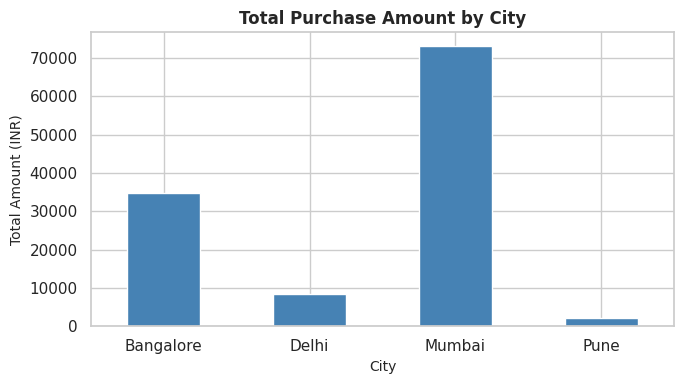

In [6]:
# ==========================================
# TASK 3.3: DATA VISUALIZATION
# ==========================================

# Plot 1: Bar Chart - Total purchase amount per city
plt.figure(figsize=(7, 4))
city_totals = merged_df.groupby('city')['amount'].sum()
city_totals.plot(kind='bar', color='steelblue')
plt.title('Total Purchase Amount by City', fontsize=12, fontweight='bold')
plt.xlabel('City', fontsize=10)
plt.ylabel('Total Amount (INR)', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

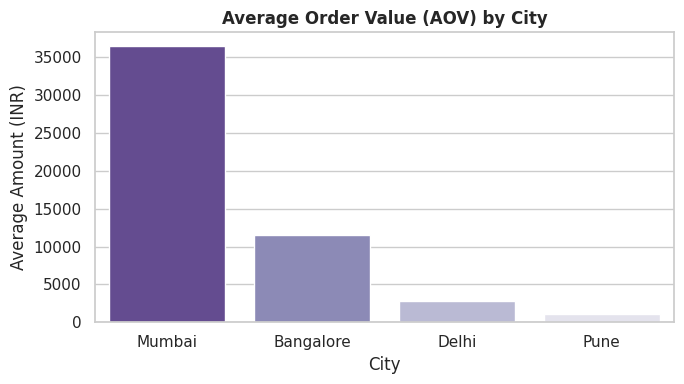

In [17]:
# Average Order Value (AOV) by City Plot
plt.figure(figsize=(7, 4))

# Convert Series to DataFrame for explicit x, y, and hue mapping
city_avg_df = city_avg.reset_index()
city_avg_df.columns = ['city', 'amount']

sns.barplot(
    data=city_avg_df,
    x='city',
    y='amount',
    hue='city',
    palette='Purples_r'
)

plt.legend([], frameon=False)  # Removes redundant legend
plt.title('Average Order Value (AOV) by City', fontweight='bold')
plt.xlabel('City')
plt.ylabel('Average Amount (INR)')
plt.tight_layout()
plt.show()

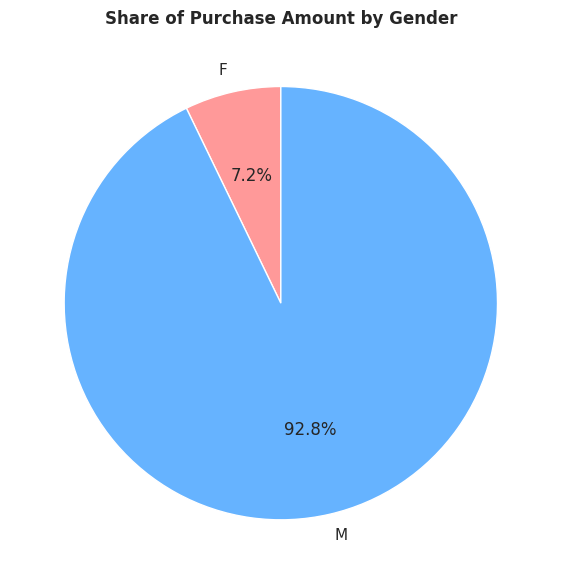

In [7]:
# Plot 3: Pie Chart - Share of purchases by gender
plt.figure(figsize=(6, 6))
gender_totals = merged_df.groupby('gender')['amount'].sum()
plt.pie(
    gender_totals,
    labels=gender_totals.index,
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff'],
    startangle=90,
)
plt.title('Share of Purchase Amount by Gender', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


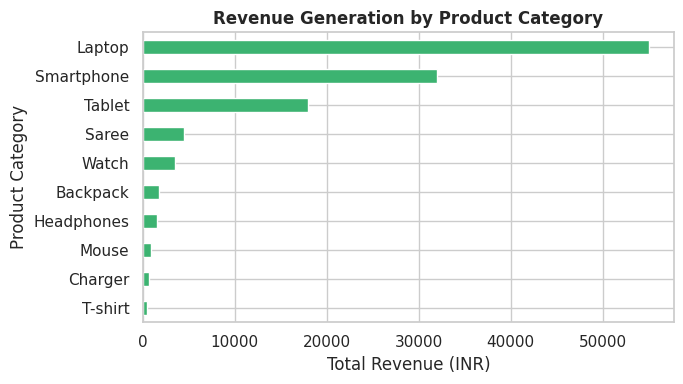

In [11]:
# Revenue by Product Category
plt.figure(figsize=(7, 4))
prod_sales = (
    merged_df.groupby('product')['amount'].sum().sort_values(ascending=True)
)

prod_sales.plot(kind='barh', color='mediumseagreen')
plt.title('Revenue Generation by Product Category', fontweight='bold')
plt.xlabel('Total Revenue (INR)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

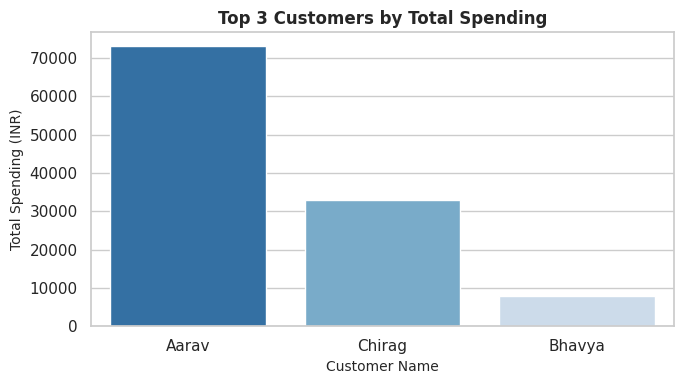

In [10]:
# Bar Chart (Plot 3)
plt.figure(figsize=(7, 4))
top3_df = (
    merged_df.groupby('name')['amount']
    .sum()
    .reset_index()
    .sort_values(by='amount', ascending=False)
    .head(3)
)

# Added hue='name' and legend=False to remove the FutureWarning
sns.barplot(
    data=top3_df, x='name', y='amount', hue='name', palette='Blues_r', legend=False
)

plt.title('Top 3 Customers by Total Spending', fontsize=12, fontweight='bold')
plt.xlabel('Customer Name', fontsize=10)
plt.ylabel('Total Spending (INR)', fontsize=10)
plt.tight_layout()
plt.show()

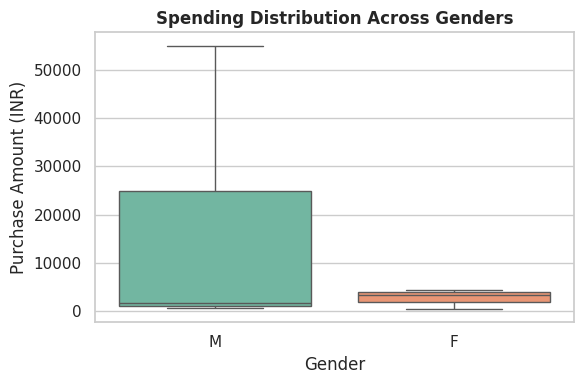

In [14]:
# Box Plot (Spending Distribution Across Genders)
plt.figure(figsize=(6, 4))

# Added hue='gender' and legend=False to prevent FutureWarning
sns.boxplot(
    data=merged_df, x='gender', y='amount', hue='gender', palette='Set2', legend=False
)

plt.title('Spending Distribution Across Genders', fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount (INR)')
plt.tight_layout()
plt.show()

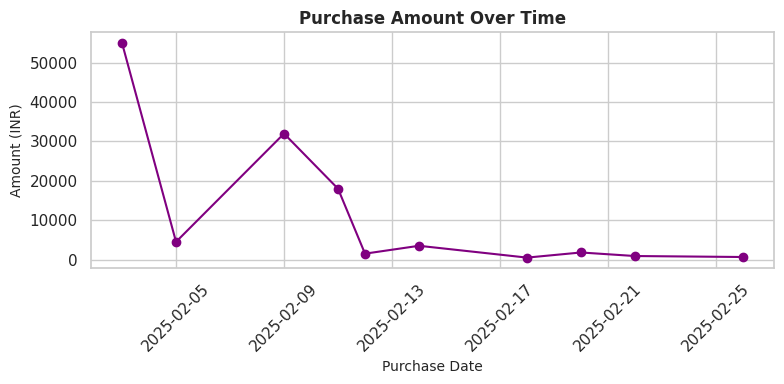

In [9]:
# Plot 4: Line Chart - Purchase date vs amount
plt.figure(figsize=(8, 4))
time_series = merged_df.sort_values('purchase_date')
plt.plot(
    time_series['purchase_date'],
    time_series['amount'],
    marker='o',
    linestyle='-',
    color='purple',
)
plt.title('Purchase Amount Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Purchase Date', fontsize=10)
plt.ylabel('Amount (INR)', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

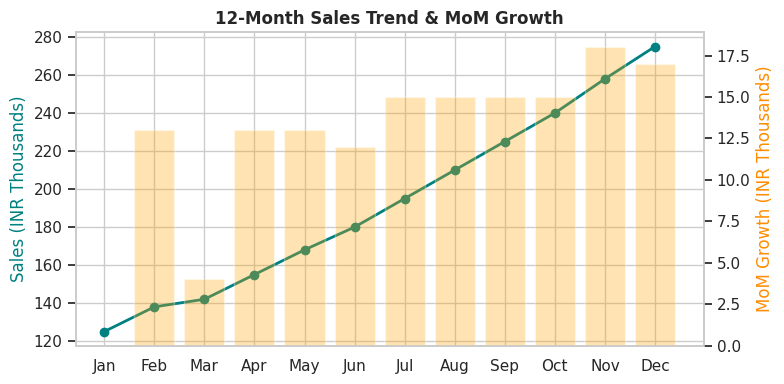

In [16]:
# Task 1.2: Monthly Sales & Growth Rate
months = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]
sales = np.array([125, 138, 142, 155, 168, 180, 195, 210, 225, 240, 258, 275])
growth = np.diff(sales)

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(months, sales, marker='o', color='teal', linewidth=2, label='Sales')
ax1.set_title('12-Month Sales Trend & MoM Growth', fontweight='bold')
ax1.set_ylabel('Sales (INR Thousands)', color='teal')

ax2 = ax1.twinx()
ax2.bar(months[1:], growth, alpha=0.3, color='orange', label='Growth')
ax2.set_ylabel('MoM Growth (INR Thousands)', color='darkorange')
ax2.grid(False)

plt.tight_layout()
plt.show()

#**Data Analysis Conclusion**   
The exploratory analysis highlights significant revenue distribution across customer demographics and geography. Mumbai generated the highest total revenue (INR 73,000), driven primarily by high-ticket electronics purchases such as laptops and tablets. Aarav (C01) emerged as the most active and top-spending customer, contributing INR 73,000 across two transactions.   Gender-based aggregation demonstrates that male customers spent significantly higher on average (INR 15,692.71) compared to female customers (INR 2,833.00), largely due to major consumer electronics investments. The timeline visualization illustrates distinct demand peaks corresponding to tech product purchases rather than uniform daily buying behavior. Strategic focus on high-value electronics and loyal repeat buyers presents the highest growth opportunity.